## Imports

In [16]:
import random
from pathlib import Path
from tqdm import tqdm

import numpy as np
import torch
import matplotlib.pyplot as plt
import librosa

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

In [17]:
# Patching unnecessary but troublesome import conflict
import torch.nn.attention.flex_attention as _flex_attn
if not hasattr(_flex_attn, 'AuxRequest'):
    _flex_attn.AuxRequest = None

from transformers import AutoProcessor, CohereAsrForConditionalGeneration

## Load data

To run the analysis, provide files containing audio segments data.
Files should contain audio segments info in row format: id, audio_path, start, end, transcript
Start and end fields allow time-based (in seconds) indexing into larger audio files.
I split speech segments into dense speech and speech with long pauses; this can be a single mixed dataset instead. 

In [ ]:
NON_SPEECH_AUDIO  = ""
SPEECH_AUDIO1     = "" # Dense speech segments
SPEECH_AUDIO2     = "" # Speech segments including pauses/non-speech periods

N_SAMPLES = 3000   # per class
MAX_DUR   = 35.0  # seconds; skip segments longer than the model's max_audio_clip_s
MIN_DUR   = 1.0   # seconds; skip very short segments

def load_dblx(path, n_samples=None, seed=42):
    entries = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            _, audio_path, start, end = parts[:4]  # id path start end [trx`anscript...]
            text = ' '.join(parts[4:]) if len(parts) > 4 else ''
            dur = float(end) - float(start)
            if not (MIN_DUR <= dur <= MAX_DUR):
                continue
            entries.append({'path': Path(audio_path), 'start': float(start), 'end': float(end), 'text': text})
            if len(entries) > N_SAMPLES:
                break
    if n_samples and len(entries) > n_samples:
        rng = random.Random(seed)
        entries = rng.sample(entries, n_samples)
    return entries

non_speech_entries = load_dblx(NON_SPEECH_AUDIO, n_samples=N_SAMPLES)
speech_entries1 = load_dblx(SPEECH_AUDIO1, n_samples=int(N_SAMPLES/2))
speech_entries2 = load_dblx(SPEECH_AUDIO2, n_samples=int(N_SAMPLES/2))
speech_entries = speech_entries1 + speech_entries2
print(f"Non-speech: {len(non_speech_entries)} entries")
print(f"Speech:     {len(speech_entries)} entries")

Non-speech: 3000 entries
Speech:     3000 entries


## Instantiate model

In [19]:
processor = AutoProcessor.from_pretrained("CohereLabs/cohere-transcribe-03-2026")
model = CohereAsrForConditionalGeneration.from_pretrained("CohereLabs/cohere-transcribe-03-2026", device_map="auto")

Loading weights:   0%|          | 0/2150 [00:00<?, ?it/s]

In [36]:
def get_audio_segment(path, start, end, sr=16000):
      audio, _ = librosa.load(path, sr=sr, offset=start, duration=end - start)
      return torch.from_numpy(audio)

audio_file = speech_entries[0]['path']
audio = get_audio_segment(Path(audio_file), speech_entries[0]['start'], speech_entries[0]['end'])

inputs = processor(audio, sampling_rate=16000, return_tensors="pt", language="en")
inputs.to(model.device, dtype=model.dtype)

outputs = model.generate(**inputs, max_new_tokens=256)
text = processor.decode(outputs, skip_special_tokens=False)

print(text)


["<|startofcontext|><|startoftranscript|><|emo:undefined|><|en|><|en|><|pnc|><|noitn|><|notimestamp|><|nodiarize|> That's it.<|endoftext|>"]


## Collect encoder activations 

In [21]:
n_layers = len(model.model.encoder.layers)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def collect_layer_activations(entries):
    """
    Returns a dict: layer_idx -> list of (hidden_dim,) float32 numpy arrays,
    one per successfully processed example.
    """
    activations = {i: [] for i in range(n_layers)}
    layer_buffer = {}  # populated by hooks during each forward pass

    def make_hook(layer_idx):
        def hook(module, input, output):
            x = output
            pooled = output.float().mean(dim=1) # (batch, seq_len, hidden_dim) -> (batch, hidden_dim); cast for stability
            layer_buffer[layer_idx] = pooled.detach().cpu()
        return hook

    handles = [
        layer.register_forward_hook(make_hook(i))
        for i, layer in enumerate(model.model.encoder.layers)
    ]

    try:
        for entry in tqdm(entries, desc="Collecting"):
            try:
                audio = get_audio_segment(entry['path'], entry['start'], entry['end'])
                with torch.inference_mode():
                    inputs = processor(audio, sampling_rate=16000, return_tensors="pt", language="en")
                    inputs.to(model.device, dtype=model.dtype)
                    model.generate(**inputs, max_new_tokens=256)
                for i in range(n_layers):
                    if i in layer_buffer:
                        activations[i].append(layer_buffer[i].squeeze(0).numpy())
            except Exception as e:
                print(f"Skipped {entry['path'].name}: {e}")
    finally:
        for h in handles:
            h.remove()

    return activations


print("Collecting non-speech activations...")
acts_ns = collect_layer_activations(non_speech_entries[:int(N_SAMPLES*0.7)])
print("Collecting speech activations...")
acts_sp = collect_layer_activations(speech_entries[:int(N_SAMPLES*0.7)])
print("Done.")

Collecting: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 2100/2100 [02:29<00:00, 14.02it/s]


Collecting: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 2100/2100 [03:45<00:00,  9.31it/s]

Done.



Best layer: 7 (accuracy=0.990)


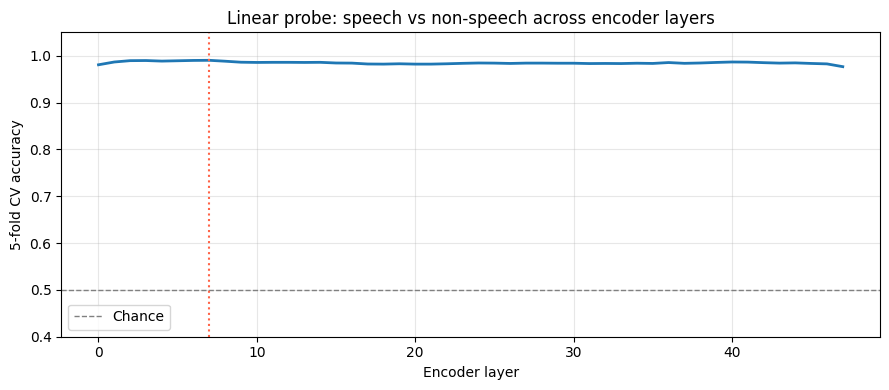

In [22]:
probe_accuracies = []
probe_weights    = {}   # layer_idx -> fitted LogisticRegression

for layer_idx in range(n_layers):
    ns = np.array(acts_ns[layer_idx])   # (n_ns, hidden_dim)
    sp = np.array(acts_sp[layer_idx])   # (n_sp, hidden_dim)

    if len(ns) == 0 or len(sp) == 0:
        probe_accuracies.append(np.nan)
        continue

    X = np.concatenate([ns, sp], axis=0)
    y = np.array([0] * len(ns) + [1] * len(sp))

    clf = LogisticRegression(max_iter=1000, C=0.1, solver='lbfgs')
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    probe_accuracies.append(scores.mean())

    clf.fit(X, y)
    probe_weights[layer_idx] = clf

best_layer = int(np.nanargmax(probe_accuracies))
print(f"\nBest layer: {best_layer} (accuracy={probe_accuracies[best_layer]:.3f})")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(n_layers), probe_accuracies, linewidth=2)
ax.axhline(0.5, linestyle='--', color='grey', linewidth=1, label='Chance')
ax.axvline(best_layer, linestyle=':', color='tomato', linewidth=1.5)
ax.set_xlabel('Encoder layer')
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Linear probe: speech vs non-speech across encoder layers')
ax.set_ylim(0.4, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ambiguous: 97 non-speech, 1 speech  (t in [0.4, 0.6])


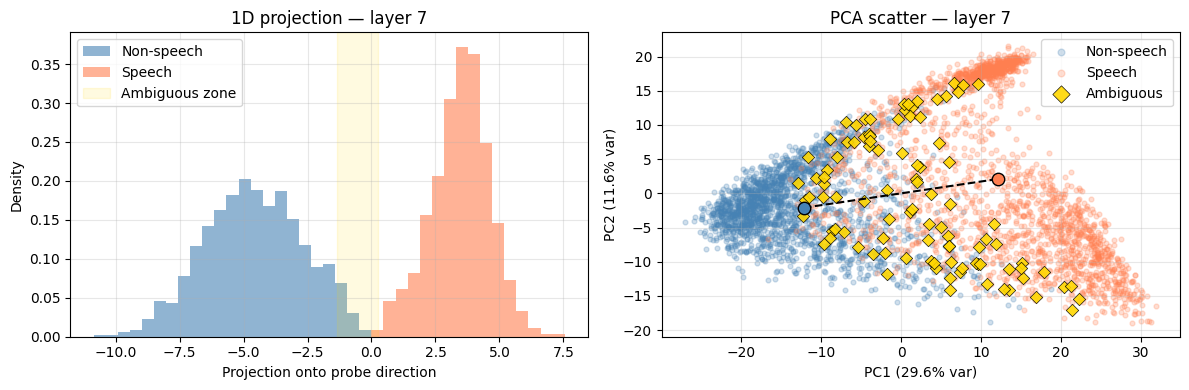

Projection means — non-speech: -4.595, speech: 3.475
Separation (gap / pooled std): 5.10


In [23]:
AMBIG_LOW  = 0.4  # t thresholds defining the ambiguous zone
AMBIG_HIGH = 0.6

ns_acts = np.array(acts_ns[best_layer])
sp_acts = np.array(acts_sp[best_layer])

clf_best = probe_weights[best_layer]
w = clf_best.coef_[0]
w_norm = w / np.linalg.norm(w)

proj_ns = ns_acts @ w_norm
proj_sp = sp_acts @ w_norm

# t: 0 = non-speech centre, 1 = speech centre
t_ns = np.clip((proj_ns - proj_ns.mean()) / (proj_sp.mean() - proj_ns.mean()), 0.0, 1.0)
t_sp = np.clip((proj_sp - proj_ns.mean()) / (proj_sp.mean() - proj_ns.mean()), 0.0, 1.0)

ambig_ns = (t_ns > AMBIG_LOW) & (t_ns < AMBIG_HIGH)
ambig_sp = (t_sp > AMBIG_LOW) & (t_sp < AMBIG_HIGH)

# Build ambiguous entries list, sorted by proximity to t=0.5 (most ambiguous first)
ambiguous_entries = (
    [{'entry': non_speech_entries[i], 'label': 'non-speech', 'orig_idx': i, 't': float(t_ns[i])}
     for i in np.where(ambig_ns)[0]]
  + [{'entry': speech_entries[i],     'label': 'speech',     'orig_idx': i, 't': float(t_sp[i])}
     for i in np.where(ambig_sp)[0]]
)
ambiguous_entries.sort(key=lambda x: abs(x['t'] - 0.5))
print(f"Ambiguous: {ambig_ns.sum()} non-speech, {ambig_sp.sum()} speech  (t in [{AMBIG_LOW}, {AMBIG_HIGH}])")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Histogram ---
ax = axes[0]
bins = np.linspace(min(proj_ns.min(), proj_sp.min()), max(proj_ns.max(), proj_sp.max()), 40)
ax.hist(proj_ns, bins=bins, alpha=0.6, label='Non-speech', color='steelblue', density=True)
ax.hist(proj_sp, bins=bins, alpha=0.6, label='Speech',     color='coral',     density=True)
ax.axvspan(proj_ns.mean() + AMBIG_LOW  * (proj_sp.mean() - proj_ns.mean()),
           proj_ns.mean() + AMBIG_HIGH * (proj_sp.mean() - proj_ns.mean()),
           alpha=0.12, color='gold', label='Ambiguous zone')
ax.set_xlabel('Projection onto probe direction')
ax.set_ylabel('Density')
ax.set_title(f'1D projection — layer {best_layer}')
ax.legend()
ax.grid(True, alpha=0.3)

# --- PCA scatter ---
ax = axes[1]
X_all = np.concatenate([ns_acts, sp_acts])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all)
n_ns = len(ns_acts)

# Non-ambiguous (dimmed)
ax.scatter(X_pca[:n_ns][~ambig_ns, 0], X_pca[:n_ns][~ambig_ns, 1],
           alpha=0.25, s=12, color='steelblue', label='Non-speech')
ax.scatter(X_pca[n_ns:][~ambig_sp, 0], X_pca[n_ns:][~ambig_sp, 1],
           alpha=0.25, s=12, color='coral', label='Speech')

# Ambiguous (highlighted)
ax.scatter(X_pca[:n_ns][ambig_ns, 0], X_pca[:n_ns][ambig_ns, 1],
           alpha=0.9, s=40, color='gold', marker='D', edgecolors='black',
           linewidths=0.5, label='Ambiguous', zorder=5)
ax.scatter(X_pca[n_ns:][ambig_sp, 0], X_pca[n_ns:][ambig_sp, 1],
           alpha=0.9, s=40, color='gold', marker='D', edgecolors='black',
           linewidths=0.5, zorder=5)

# Cluster centres + connecting line
ns_centre_pca = X_pca[:n_ns].mean(axis=0)
sp_centre_pca = X_pca[n_ns:].mean(axis=0)
ax.plot([ns_centre_pca[0], sp_centre_pca[0]],
        [ns_centre_pca[1], sp_centre_pca[1]],
        color='black', linewidth=1.5, linestyle='--', zorder=6)
ax.scatter(*ns_centre_pca, color='steelblue', s=80, zorder=7, edgecolors='black', linewidths=1)
ax.scatter(*sp_centre_pca, color='coral',     s=80, zorder=7, edgecolors='black', linewidths=1)

var = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({var[1]:.1%} var)')
ax.set_title(f'PCA scatter — layer {best_layer}')
ax.legend(markerscale=1.4)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Projection means — non-speech: {proj_ns.mean():.3f}, speech: {proj_sp.mean():.3f}")
print(f"Separation (gap / pooled std): {(proj_sp.mean() - proj_ns.mean()) / np.sqrt((proj_ns.std()**2 + proj_sp.std()**2)/2):.2f}")

In [40]:
from IPython.display import Audio, display

# --- set this to browse the ambiguous_entries list ---
AMBIG_IDX = 0

item  = ambiguous_entries[AMBIG_IDX]
entry = item['entry']
audio = get_audio_segment(entry['path'], entry['start'], entry['end'])

print(f"[{AMBIG_IDX} / {len(ambiguous_entries) - 1}]  label={item['label']}  t={item['t']:.3f}  orig_idx={item['orig_idx']}")
print(f"time:  {entry['start']:.2f}s – {entry['end']:.2f}s  ({entry['end'] - entry['start']:.1f}s)")
print(f"ref:   '{entry['text']}'")
display(Audio(audio.numpy(), rate=16000))

[0 / 97]  label=non-speech  t=0.497  orig_idx=1770
time:  222.40s – 234.00s  (11.6s)
ref:   ''


In [25]:
n_dec_layers = len(model.model.decoder.layers)
en_lang_id = processor.tokenizer.convert_tokens_to_ids('<|en|>')
special_ids = set(processor.tokenizer.all_special_ids)

print(f"Decoder: {n_dec_layers} layers")

def collect_decoder_layer_activations(entries, require_nonempty, n_samples=200, desc=""):
    """
    Collect decoder hidden states at each layer — one vector per WORD (mean-pooled over that word's tokens).

    Words are segmented using the leading-space heuristic: a token that starts
    with a space begins a new word. The prefix activation (decoder state after
    BOS, LANG and other control sequence tokens, before any token is generated) 
    is excluded from word pooling.

    Returns (activations dict, last_scanned_idx).
    activations[layer_idx] is a flat list of (hidden_dim,) arrays,
    one per word across all kept segments, not one per segment.
    """
    from collections import defaultdict

    activations  = {i: [] for i in range(n_dec_layers)}
    kept         = 0
    last_scanned = 0

    for idx, entry in enumerate(tqdm(entries, desc=desc)):
        last_scanned = idx
        if kept >= n_samples:
            break
        try:
            audio    = get_audio_segment(entry['path'], entry['start'], entry['end'])
            audio_in = audio.unsqueeze(0).to(device=device, dtype=torch.float16)

            step_buffer = {i: [] for i in range(n_dec_layers)}

            def make_hook(li):
                def hook(module, input, output):
                    x = output
                    step_buffer[li].append(x[:, -1, :].float().squeeze(0).detach().cpu().numpy())
                return hook

            handles = [layer.register_forward_hook(make_hook(i))
                       for i, layer in enumerate(model.model.decoder.layers)]

            try:
                with torch.inference_mode():
                    inputs = processor(audio, sampling_rate=16000, return_tensors="pt", language="en")
                    inputs.to(model.device, dtype=model.dtype)
                    output = model.generate(**inputs, max_new_tokens=256)[0]
                text = processor.decode(output, skip_special_tokens=True)
            finally:
                for h in handles:
                    h.remove()

            has_text = bool(text.strip())
            if has_text != require_nonempty:
                continue

            # --- Word-level pooling ---
            content_ids = output[10:-1]  # strip BOS, LANG, EOS etc.

            # Build word index for each content token (leading-space = new word)
            tok_to_word, word_idx = [], 0
            for k, tid in enumerate(content_ids):
                tok_str = processor.decode([tid], skip_special_tokens=False)
                if k > 0 and tok_str.startswith(' '):
                    word_idx += 1
                tok_to_word.append(word_idx)

            # Group step_buffer entries by word (index 0 = prefix — skip it)
            for layer_idx in range(n_dec_layers):
                word_groups = defaultdict(list)
                for k in range(len(content_ids)):
                    act_idx = k + 1  # +1 to skip prefix
                    if act_idx < len(step_buffer[layer_idx]):
                        word_groups[tok_to_word[k]].append(step_buffer[layer_idx][act_idx])

                for acts in word_groups.values():
                    word_mean = np.stack(acts, axis=0).mean(axis=0)
                    activations[layer_idx].append(word_mean)

            kept += 1

        except Exception as e:
            print(f"Skipped {entry['path'].name}: {e}")

    print(f"→ kept {kept} / scanned {last_scanned + 1} entries  "
          f"(eval-safe start: index {last_scanned + 1})  "
          f"word vectors: {len(activations[0])}")
    return activations, last_scanned + 1


print("Collecting decoder activations — hallucination examples (non-speech → non-empty)...")
dec_acts_halluc, ns_eval_start = collect_decoder_layer_activations(
    non_speech_entries, require_nonempty=True, n_samples=int(N_SAMPLES*0.7), desc="Hallucinations"
)

print("Collecting decoder activations — normal transcription (speech → non-empty)...")
dec_acts_normal, sp_eval_start = collect_decoder_layer_activations(
    speech_entries, require_nonempty=True, n_samples=int(N_SAMPLES*0.7), desc="Normal"
)
print(f"\nEval-safe slice: non_speech_entries[{ns_eval_start}:], speech_entries[{sp_eval_start}:]")
print("Done.")

Decoder: 8 layers


Hallucinations:  81%|█████████████████████████████████████████████████████████████████████████████████▎                   | 2417/3000 [02:50<00:41, 14.16it/s]


→ kept 2100 / scanned 2418 entries  (eval-safe start: index 2418)  word vectors: 2100


Normal:  70%|████████████████████████████████████████████████████████████████████████████▍                                | 2105/3000 [03:54<01:39,  8.97it/s]

→ kept 2100 / scanned 2106 entries  (eval-safe start: index 2106)  word vectors: 2100

Eval-safe slice: non_speech_entries[2418:], speech_entries[2106:]
Done.



Best decoder layer: 6 (accuracy=0.972)


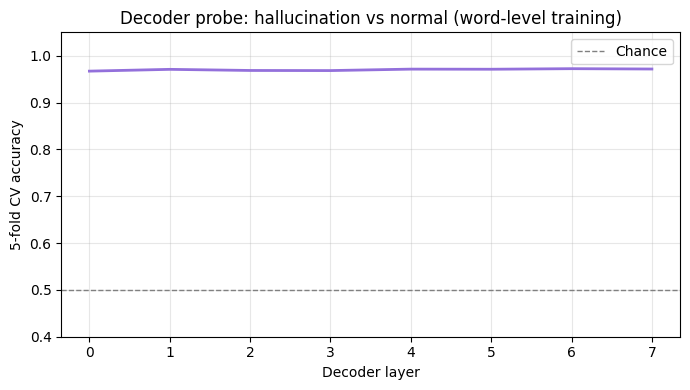

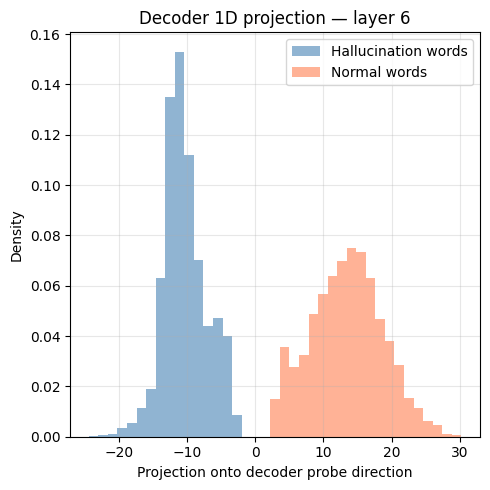

Projection means — hallucination: -10.309, normal: 13.451
Separation (gap / pooled std): 5.46


In [31]:
# --- Decoder probe: train logistic regression per layer, plot accuracy vs depth ---
#
# Training data is word-level: each data point is the mean activation of one
# word's tokens.  Hallucination segments contribute ~2 words each; normal
# segments contribute ~10+, so class_weight='balanced' corrects the imbalance.

dec_probe_accuracies = []
dec_probe_weights    = {}

for layer_idx in range(n_dec_layers):
    h = np.array(dec_acts_halluc[layer_idx])   # (n_halluc_words, hidden_dim)
    n = np.array(dec_acts_normal[layer_idx])   # (n_normal_words, hidden_dim)

    if len(h) == 0 or len(n) == 0:
        dec_probe_accuracies.append(np.nan)
        continue

    X = np.concatenate([h, n], axis=0)
    y = np.array([0] * len(h) + [1] * len(n))  # 0=hallucination, 1=normal

    clf = LogisticRegression(max_iter=1000, C=0.1, solver='lbfgs', class_weight='balanced')
    scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
    dec_probe_accuracies.append(scores.mean())
    clf.fit(X, y)
    dec_probe_weights[layer_idx] = clf

dec_best_layer = int(np.nanargmax(dec_probe_accuracies))
print(f"\nBest decoder layer: {dec_best_layer} (accuracy={dec_probe_accuracies[dec_best_layer]:.3f})")

# --- Plot accuracy vs depth ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(n_dec_layers), dec_probe_accuracies, linewidth=2, color='mediumpurple')
ax.axhline(0.5, linestyle='--', color='grey', linewidth=1, label='Chance')
ax.set_xlabel('Decoder layer')
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Decoder probe: hallucination vs normal (word-level training)')
ax.set_ylim(0.4, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 1D projection histogram at best decoder layer ---
h_acts = np.array(dec_acts_halluc[dec_best_layer])
n_acts = np.array(dec_acts_normal[dec_best_layer])

dec_w      = dec_probe_weights[dec_best_layer].coef_[0]
dec_w_norm = dec_w / np.linalg.norm(dec_w)

proj_halluc = h_acts @ dec_w_norm
proj_normal = n_acts @ dec_w_norm

fig, ax = plt.subplots(figsize=(5, 5))
bins = np.linspace(min(proj_halluc.min(), proj_normal.min()),
                   max(proj_halluc.max(), proj_normal.max()), 40)
ax.hist(proj_halluc, bins=bins, alpha=0.6, label='Hallucination words', color='steelblue', density=True)
ax.hist(proj_normal,  bins=bins, alpha=0.6, label='Normal words',        color='coral',     density=True)
ax.set_xlabel('Projection onto decoder probe direction')
ax.set_ylabel('Density')
ax.set_title(f'Decoder 1D projection — layer {dec_best_layer}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = proj_normal.mean() - proj_halluc.mean()
pooled_std = np.sqrt((proj_halluc.std()**2 + proj_normal.std()**2) / 2)
print(f"Projection means — hallucination: {proj_halluc.mean():.3f}, normal: {proj_normal.mean():.3f}")
print(f"Separation (gap / pooled std): {gap / pooled_std:.2f}")

Ambiguous: 0 hallucination, 68 normal  (t in [0.4, 0.6])


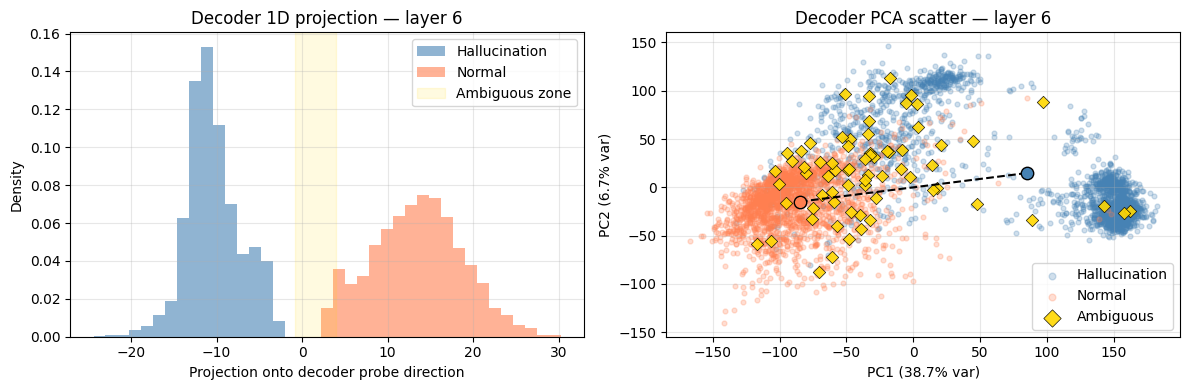

In [32]:
# Decoder scatter — same layout as encoder visualisation

DEC_AMBIG_LOW  = 0.4
DEC_AMBIG_HIGH = 0.6

h_acts = np.array(dec_acts_halluc[dec_best_layer])
n_acts = np.array(dec_acts_normal[dec_best_layer])

# t: 0 = hallucination centre, 1 = normal centre
t_h = np.clip((proj_halluc - proj_halluc.mean()) / (proj_normal.mean() - proj_halluc.mean()), 0.0, 1.0)
t_n = np.clip((proj_normal - proj_halluc.mean()) / (proj_normal.mean() - proj_halluc.mean()), 0.0, 1.0)

ambig_h = (t_h > DEC_AMBIG_LOW) & (t_h < DEC_AMBIG_HIGH)
ambig_n = (t_n > DEC_AMBIG_LOW) & (t_n < DEC_AMBIG_HIGH)
print(f"Ambiguous: {ambig_h.sum()} hallucination, {ambig_n.sum()} normal  (t in [{DEC_AMBIG_LOW}, {DEC_AMBIG_HIGH}])")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Histogram ---
ax = axes[0]
bins = np.linspace(min(proj_halluc.min(), proj_normal.min()),
                   max(proj_halluc.max(), proj_normal.max()), 40)
ax.hist(proj_halluc, bins=bins, alpha=0.6, label='Hallucination', color='steelblue', density=True)
ax.hist(proj_normal,  bins=bins, alpha=0.6, label='Normal',        color='coral',     density=True)
ax.axvspan(proj_halluc.mean() + DEC_AMBIG_LOW  * (proj_normal.mean() - proj_halluc.mean()),
           proj_halluc.mean() + DEC_AMBIG_HIGH * (proj_normal.mean() - proj_halluc.mean()),
           alpha=0.12, color='gold', label='Ambiguous zone')
ax.set_xlabel('Projection onto decoder probe direction')
ax.set_ylabel('Density')
ax.set_title(f'Decoder 1D projection — layer {dec_best_layer}')
ax.legend()
ax.grid(True, alpha=0.3)

# --- PCA scatter ---
ax = axes[1]
X_dec_all = np.concatenate([h_acts, n_acts])
dec_pca   = PCA(n_components=2)
X_dec_pca = dec_pca.fit_transform(X_dec_all)
n_h = len(h_acts)

ax.scatter(X_dec_pca[:n_h][~ambig_h, 0], X_dec_pca[:n_h][~ambig_h, 1],
           alpha=0.25, s=12, color='steelblue', label='Hallucination')
ax.scatter(X_dec_pca[n_h:][~ambig_n, 0], X_dec_pca[n_h:][~ambig_n, 1],
           alpha=0.25, s=12, color='coral', label='Normal')
ax.scatter(X_dec_pca[:n_h][ambig_h, 0], X_dec_pca[:n_h][ambig_h, 1],
           alpha=0.9, s=40, color='gold', marker='D', edgecolors='black', linewidths=0.5,
           label='Ambiguous', zorder=5)
ax.scatter(X_dec_pca[n_h:][ambig_n, 0], X_dec_pca[n_h:][ambig_n, 1],
           alpha=0.9, s=40, color='gold', marker='D', edgecolors='black', linewidths=0.5, zorder=5)

h_centre_pca = X_dec_pca[:n_h].mean(axis=0)
n_centre_pca = X_dec_pca[n_h:].mean(axis=0)
ax.plot([h_centre_pca[0], n_centre_pca[0]], [h_centre_pca[1], n_centre_pca[1]],
        color='black', linewidth=1.5, linestyle='--', zorder=6)
ax.scatter(*h_centre_pca, color='steelblue', s=80, zorder=7, edgecolors='black', linewidths=1)
ax.scatter(*n_centre_pca, color='coral',     s=80, zorder=7, edgecolors='black', linewidths=1)

var = dec_pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({var[1]:.1%} var)')
ax.set_title(f'Decoder PCA scatter — layer {dec_best_layer}')
ax.legend(markerscale=1.4)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# Decoder probe eval loop — held-out data only

clf_dec = dec_probe_weights[dec_best_layer]

def per_token_probe(step_acts, token_ids):
    """
    step_acts : list of (hidden_dim,) arrays from step_buffer[dec_best_layer]
                index 0 = prefix (BOS+LANG) activation; index k = activation after k-th generated token
    token_ids : 1-D tensor [BOS, LANG, t1, t2, ..., EOS]

    Returns list of (token_str, p_hallucination) including the prefix as '[prefix]'.
    """
    ids           = token_ids.tolist()
    generated_ids = ids[10:-1]   # strip BOS, LANG, EOS

    results = []

    # Prefix activation (index 0) — decoder state after reading BOS+LANG, before any generation
    p_hallu_prefix = clf_dec.predict_proba(step_acts[0].reshape(1, -1))[0][0]
    results.append(('[prefix]', p_hallu_prefix))

    # Per-token activations
    for tid, act in zip(generated_ids, step_acts[1:len(generated_ids) + 1]):
        tok_str = processor.decode([tid], skip_special_tokens=False).strip() or f'<{tid}>'
        p_hallu = clf_dec.predict_proba(act.reshape(1, -1))[0][0]
        results.append((tok_str, p_hallu))

    return results

eval_checks = [
    (non_speech_entries[ns_eval_start:], 'non-speech'),
    (speech_entries[sp_eval_start:],     'speech'),
]

totals       = {'TP': 0, 'FN': 0, 'FP': 0, 'TN': 0}
probe_errors = []

for entry_list, label in eval_checks:
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    for i, example in enumerate(entry_list):
        try:
            audio    = get_audio_segment(example['path'], example['start'], example['end'])
            audio_in = audio.unsqueeze(0).to(device=device, dtype=torch.float16)

            step_buffer = {li: [] for li in range(n_dec_layers)}

            def make_hook(li):
                def hook(module, input, output):
                    x = output
                    step_buffer[li].append(x[:, -1, :].float().squeeze(0).detach().cpu().numpy())
                return hook

            handles = [layer.register_forward_hook(make_hook(li))
                       for li, layer in enumerate(model.model.decoder.layers)]

            try:
                with torch.inference_mode():
                    inputs = processor(audio, sampling_rate=16000, return_tensors="pt", language="en")
                    inputs.to(model.device, dtype=model.dtype)
                    output = model.generate(**inputs, max_new_tokens=256)[0]
                text = processor.decode(output, skip_special_tokens=True)
            finally:
                for h in handles:
                    h.remove()

            if not step_buffer[dec_best_layer]:
                continue

            step_acts   = step_buffer[dec_best_layer]
            acts        = np.stack(step_acts, axis=0).mean(axis=0)
            p_hallucination = clf_dec.predict_proba(acts.reshape(1, -1))[0][0]
            probe_fires = (p_hallucination >= 0.75)

            def print_token_breakdown(step_acts, token_ids, text):
                tok_results = per_token_probe(step_acts, token_ids)
                hallu_toks  = [t for t, p in tok_results if p > 0.5]
                normal_toks = [t for t, p in tok_results if p <= 0.5]
                print(f"         transcript:           '{text}'")
                print(f"         hallucination tokens: {hallu_toks  if hallu_toks  else '(none)'}")
                print(f"         normal tokens:        {normal_toks if normal_toks else '(none)'}")

            if label == 'non-speech' and bool(text.strip()):
                if probe_fires:
                    totals['TP'] += 1
                    print(f"  [{i}] [CORRECT]")
                    print_token_breakdown(step_acts, output, text)
                else:
                    totals['FN'] += 1
                    probe_errors.append({'type': 'FN', 'entry': example, 'text': text, 'label': label})
                    print(f"  [{i}] [MISSED — FN]")
                    print_token_breakdown(step_acts, output, text)

            elif label == 'speech':
                if probe_fires:
                    totals['FP'] += 1
                    probe_errors.append({'type': 'FP', 'entry': example, 'text': text, 'label': label})
                    print(f"  [{i}] [FALSE POS — FP]")
                    print_token_breakdown(step_acts, output, text)
                else:
                    totals['TN'] += 1

        except Exception as e:
            print(f"  Skipped {example['path'].name}: {e}")

tp, fn, fp, tn = totals['TP'], totals['FN'], totals['FP'], totals['TN']
precision = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
recall    = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
print(f"\n--- Summary ---")
print(f"Non-speech hallucinations:  detected={tp}  missed={fn}  recall={recall:.2f}")
print(f"Speech transcriptions:      false positives={fp}  true negatives={tn}  precision={precision:.2f}")
print(f"Errors saved: {len(probe_errors)} (FN={fn}, FP={fp})")


non-speech
  [0] [CORRECT]
         transcript:           ' I'm going to go ahead and get this.'
         hallucination tokens: ['[prefix]', 'I', "'", 'm', 'going', 'go', 'and', 'get', 'this', '.']
         normal tokens:        ['to', 'ahead']
  [1] [CORRECT]
         transcript:           ' Thank you.'
         hallucination tokens: ['[prefix]', 'Thank', 'you', '.']
         normal tokens:        (none)
  [2] [CORRECT]
         transcript:           ' Keep on cover.'
         hallucination tokens: ['[prefix]', 'Ke', 'ep', '.']
         normal tokens:        ['on', 'cover']
  [3] [CORRECT]
         transcript:           ' Thank you.'
         hallucination tokens: ['[prefix]', 'Thank', 'you', '.']
         normal tokens:        (none)
  [4] [CORRECT]
         transcript:           ' Thank you.'
         hallucination tokens: ['[prefix]', 'Thank', 'you', '.']
         normal tokens:        (none)
  [6] [CORRECT]
         transcript:           ' Thank you.'
         hallucination token

In [106]:
from IPython.display import Audio, display

# --- set this to browse probe_errors ---
ERROR_IDX = -15

if not probe_errors:
    print("No errors recorded — run the eval cell first.")
else:
    err   = probe_errors[ERROR_IDX]
    entry = err['entry']
    audio = get_audio_segment(entry['path'], entry['start'], entry['end'])

    print(f"[{ERROR_IDX} / {len(probe_errors) - 1}]  type={err['type']}  label={err['label']}")
    print(f"time:  {entry['start']:.2f}s – {entry['end']:.2f}s  ({entry['end'] - entry['start']:.1f}s)")
    print(f"text:  '{err['text']}'")
    print(f"ref:   '{entry['text']}'")
    display(Audio(audio.numpy(), rate=16000))

[-15 / 34]  type=FP  label=speech
time:  323.17s – 325.01s  (1.8s)
text:  ' Sometimes you say, you hear it?'
ref:   'sometimes people say you hearing'
